In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import eigh
from qiskit.quantum_info import SparsePauliOp,Statevector
from qiskit.circuit.library import EfficientSU2,TwoLocal
from qiskit.primitives import StatevectorEstimator,StatevectorSampler
from qiskit_algorithms import VQE, VQD
from qiskit.circuit.library import n_local
from qiskit_algorithms.optimizers import COBYLA
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_algorithms.state_fidelities import ComputeUncompute
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
def build_tfim(n, J, h):
    terms = []
    for i in range(n - 1):
        z = ["I"] * n
        z[i] = "Z"
        z[i + 1] = "Z"
        terms.append(("".join(z), -J))
    for i in range(n):
        x = ["I"] * n
        x[i] = "X"
        terms.append(("".join(x), -h))
    return SparsePauliOp.from_list(terms)

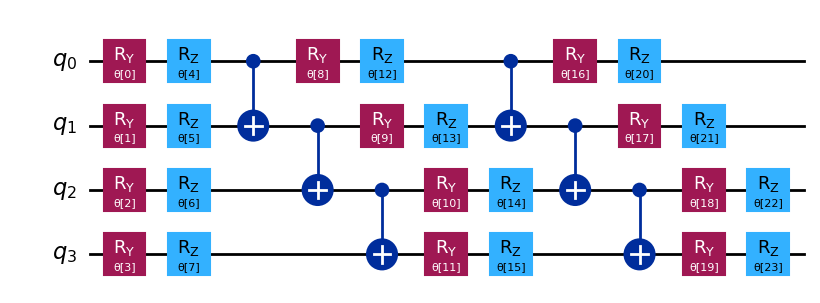

In [3]:
def tfim_ansatz(n,reps=2, entanglement="linear"):
    return TwoLocal(
        n,
        rotation_blocks=['ry','rz'],
        entanglement_blocks='cx',
        entanglement=entanglement,
        reps=reps
    )
ansatz = tfim_ansatz(4, reps=2, entanglement="linear")
optimizer = COBYLA(
    maxiter=300,
    tol=1e-6
)
ansatz.decompose().draw("mpl")

In [4]:
#1
def VQE_ground_energy(H, n,reps,entanglement):
    energies = []
    def callback(eval_count, params, energy, metadata):
        energies.append(energy)
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=500)
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback
    )
    result = vqe.compute_minimum_eigenvalue(H)
    return energies, result.eigenvalue.real

In [5]:
#2
def VQD_excited_n_energy(H,n,state,reps,entanglement):
    ansatz = tfim_ansatz(n,reps=reps, entanglement=entanglement)
    optimizer = COBYLA(maxiter=500)
    estimator = StatevectorEstimator()
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler)
    vqd = VQD(
        estimator=estimator,
        fidelity=fidelity,
        ansatz=ansatz,
        optimizer=optimizer,
        k=state,
        betas=[25]
    )
    result = vqd.compute_eigenvalues(H)
    return result.eigenvalues[1].real

In [6]:
def exact_n_energy(H,n):
    eigvals = np.linalg.eigvalsh(H.to_matrix())
    return eigvals[n]

In [7]:
n = 4
J = 1
h = 1
H = build_tfim(n,J,h)
exact_energy = exact_n_energy(H,0)
depths = [1,2,3,4]
linear_errors = []
full_errors = []
circular_errors = []
for d in depths:
    eng_list_lr,e_linear = VQE_ground_energy(H,n,d,"linear")
    eng_list_fl,e_full = VQE_ground_energy(H,n,d,"full")
    eng_list_cl,e_circular = VQE_ground_energy(H,n,d,"circular")
    linear_errors.append(abs(e_linear - exact_energy))
    full_errors.append(abs(e_full - exact_energy))
    circular_errors.append(abs(e_circular - exact_energy))
param_counts_linear= []
param_counts_full = []
param_counts_circular = []
for r in depths:
    ansatz = tfim_ansatz(n,reps=r, entanglement="linear")
    param_counts_linear.append(ansatz.num_parameters)
    ansatz = tfim_ansatz(n,reps=r, entanglement="full")
    param_counts_full.append(ansatz.num_parameters)
    ansatz = tfim_ansatz(n,reps=r, entanglement="circular")
    param_counts_circular.append(ansatz.num_parameters)
print('linear_errors:',linear_errors)
print('full_errors:',full_errors)
print('circular_errors:',circular_errors)
print('Parameters Counts (Linear):',param_counts_linear)
print('Parameters Counts (Full):',param_counts_full)
print('Parameters Counts (Circular):',param_counts_circular)

linear_errors: [0.024540861237420053, 0.29720734622482503, 0.014096208001447508, 0.07979259898599445]
full_errors: [0.08098747355311087, 0.2128553258832273, 0.12780231524448116, 0.03800535197088806]
circular_errors: [1.1228586494350594, 0.007804959207426521, 0.33429603471640057, 0.04137490233814223]
Parameters Counts (Linear): [16, 24, 32, 40]
Parameters Counts (Full): [16, 24, 32, 40]
Parameters Counts (Circular): [16, 24, 32, 40]


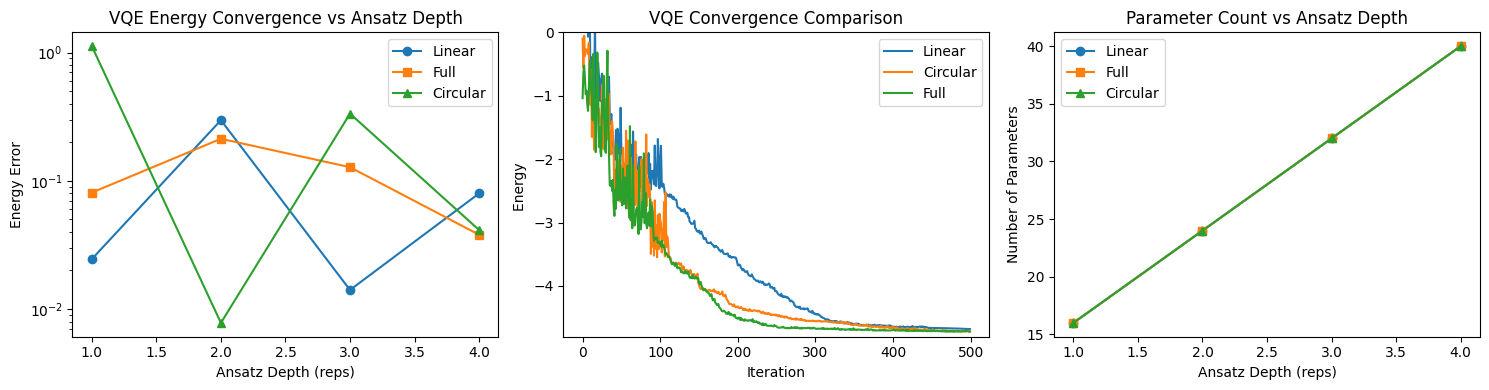

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot(depths vs errors)
axes[0].plot(depths, linear_errors, marker="o", label="Linear")
axes[0].plot(depths, full_errors, marker="s", label="Full")
axes[0].plot(depths, circular_errors, marker="^", label="Circular")
axes[0].set_yscale("log")
axes[0].set_title("VQE Energy Convergence vs Ansatz Depth")
axes[0].set_xlabel("Ansatz Depth (reps)")
axes[0].set_ylabel("Energy Error")
axes[0].legend()
# 2nd subplot(convergence vs different type of entanglement )
axes[1].plot(eng_list_lr, label="Linear")
axes[1].plot(eng_list_cl, label="Circular")
axes[1].plot(eng_list_fl, label="Full")
axes[1].set_title("VQE Convergence Comparison")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Energy ")
axes[1].set_ylim(-4.8,0)
axes[1].legend()
#3rd subplot (parameters count vs different type of entanglement)
axes[2].plot(depths, param_counts_linear, marker="o", label="Linear")
axes[2].plot(depths, param_counts_full, marker="s", label="Full")
axes[2].plot(depths, param_counts_circular, marker="^", label="Circular")
axes[2].set_title("Parameter Count vs Ansatz Depth")
axes[2].set_xlabel("Ansatz Depth (reps)")
axes[2].set_ylabel("Number of Parameters")
axes[2].legend()
plt.tight_layout()
plt.show()

In [9]:
#Inferences
#General beleif increasing depth to reduce energy gap isnt working!!
#here also linear shows better results
#Parameter count stays constant

In [10]:
n = 4
J = 1
d=5
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    eq,E0 = VQE_ground_energy(H,n,d,entanglement)
    E1 = VQD_excited_n_energy(H, n,2,d,entanglement)
    E0_quantum.append(E0)
    E1_quantum.append(E1)
    gaps_quantum.append(E1 - E0)
    gaps_error.append(np.abs(E1 - E0 - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1-E0:.4f};Ground={E0:.4f};excited={E1:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=3.9428;Ground=-8.2725;excited=-4.3297
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=3.7762;Ground=-8.7386;excited=-4.9624
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=3.3607;Ground=-9.0918;excited=-5.7311
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=4.7978;Ground=-9.5770;excited=-4.7792
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=4.9404;Ground=-10.0626;excited=-5.1222
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=5.8466;Ground=-10.4388;excited=-4.5922
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=6.1065;Ground=-10.8648;excited=-4.7583
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=5.9481;Ground=-11.1549;excited=-5.2068
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=5.4680;Groun

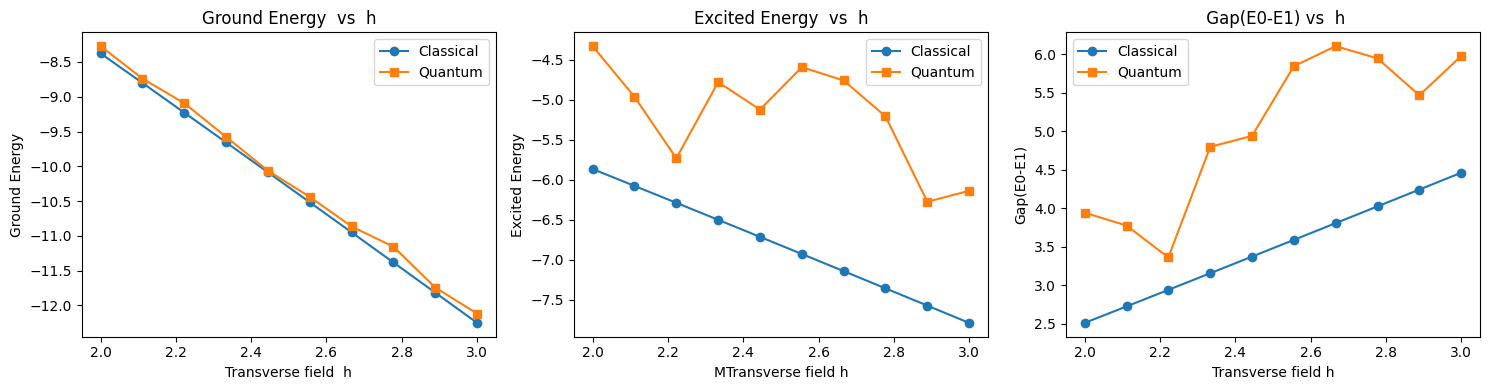

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [12]:
#VQD is performing soo bad !!
#what the heck this,I changed intializer ,increased depth, changed betas but no improvement in results,
#I am getting very bad results for excited state energy, even the gap error is huge,
#I am not sure what is going wrong here, I will try to debug this later, 
#I add ssvqe results for comparison, but still no improvement in results, I am getting very bad results for excited state energy, even the gap error is huge, I am not sure what is going wrong here, I will try to debug this later,


In [13]:
def SSVQE_energies(H, n, reps=4, entanglement="full", runs=15):
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    def basis_state(i):
        state = np.zeros(2**n)
        if i == 0:
            state[0] = 1
        elif i == 1:
            state[2**(n-1)] = 1
        return Statevector(state)
    best_cost = 1e10
    best_theta = None
    for _ in range(runs):
        theta0 = np.random.random(ansatz.num_parameters)
        def cost(theta):
            U = ansatz.assign_parameters(theta)
            weights = [1,5]
            total_energy = 0
            for i in range(2):
                psi = basis_state(i).evolve(U)
                energy = np.real(psi.expectation_value(H))
                total_energy += weights[i]*energy
            return total_energy
        result = minimize(
            cost,
            theta0,
            method="COBYLA",
            options={"maxiter":200}
        )
        if result.fun < best_cost:
            best_cost = result.fun
            best_theta = result.x
    U = ansatz.assign_parameters(best_theta)
    energies = []
    for i in range(2):
        psi = basis_state(i).evolve(U)
        energy = np.real(psi.expectation_value(H))
        energies.append(energy)
    E0, E1 = energies
    return E0, E1, E1 - E0

In [14]:
n = 4
J = 1
d=3
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    E0, E1, gap = SSVQE_energies(H, n, reps=d, entanglement=entanglement)
    eq,E0_q=VQE_ground_energy(H,n,d,entanglement)
    E0_quantum.append(E0_q)
    E1_quantum.append(E1) 
    gaps_quantum.append(E1 - E0_q)
    gaps_error.append(np.abs(E1 - E0_q - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1-E0_q:.4f};Ground={E0_q:.4f};excited={E1:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=0.1076;Ground=-8.3261;excited=-8.2184
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=0.1868;Ground=-8.7908;excited=-8.6040
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=0.0439;Ground=-9.1147;excited=-9.0708
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=0.0962;Ground=-9.5680;excited=-9.4719
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=-0.0450;Ground=-9.9354;excited=-9.9804
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=0.1222;Ground=-10.5043;excited=-10.3821
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=0.0608;Ground=-10.9211;excited=-10.8603
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=0.0792;Ground=-11.3585;excited=-11.2793
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=0.0487;Gr

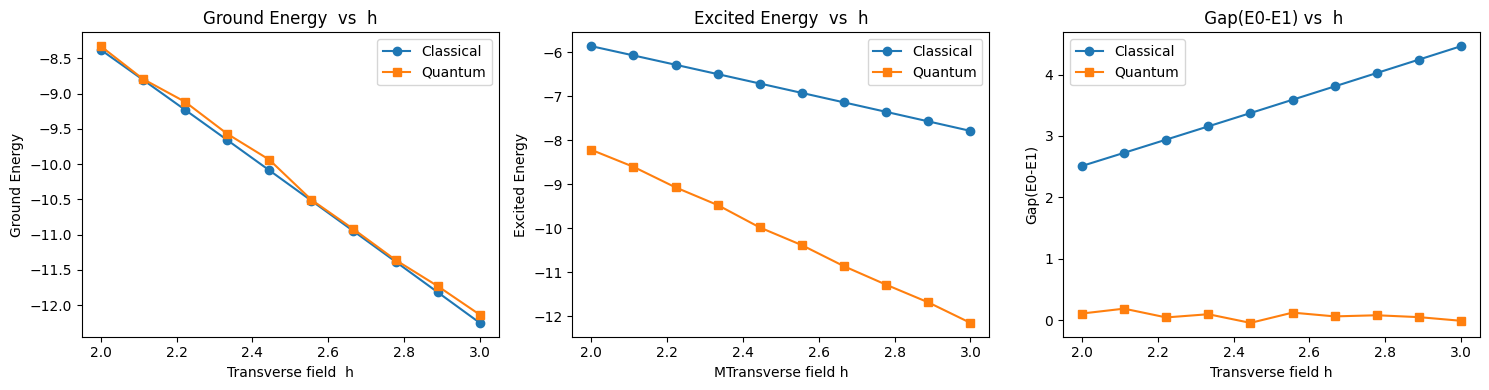

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [26]:
#SSVQE is performing better than VQD but still the results are not good, the gap error is still huge, I am not sure what is going wrong here, I will try to debug this by new method called Quantum subspace expansion``

In [17]:
def QSE_energies(H, psi0, n):
    ops = []
    ops.append(SparsePauliOp.from_list([("I"*n,1)]))
    for i in range(n):
        p = ["I"]*n
        p[i] = "X"
        ops.append(SparsePauliOp.from_list([("".join(p),1)]))
    for i in range(n):
        p = ["I"]*n
        p[i] = "Z"
        ops.append(SparsePauliOp.from_list([("".join(p),1)]))
    dim = len(ops)
    Hmat = np.zeros((dim,dim))
    Smat = np.zeros((dim,dim))
    for i in range(dim):
        for j in range(dim):
            psi_i = psi0.evolve(ops[i])
            psi_j = psi0.evolve(ops[j])
            Hmat[i,j] = np.real(
                np.vdot(psi_i.data, psi_j.evolve(H).data)
            )
            Smat[i,j] = np.real(
                np.vdot(psi_i.data, psi_j.data)
            )
    energies,_ = eigh(Hmat,Smat)

    energies = np.sort(energies)

    return energies

In [18]:
def VQE_ground_energy(H, n, reps, entanglement):
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    optimizer = COBYLA(maxiter=500)
    estimator = StatevectorEstimator()
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )
    result = vqe.compute_minimum_eigenvalue(H)
    optimal_params = result.optimal_point
    ground_energy = result.eigenvalue.real
    psi0 = Statevector.from_label("0"*n).evolve(
        ansatz.assign_parameters(optimal_params)
    )
    return psi0, optimal_params, ground_energy

In [19]:
n = 4
J = 1
d=3
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    psi0,eq,E0_q=VQE_ground_energy(H,n,d,entanglement)
    E1_q=QSE_energies(H,psi0,n)[1]
    E0_quantum.append(E0_q)
    E1_quantum.append(E1_q)
    gaps_quantum.append(E1_q - E0_q)
    gaps_error.append(np.abs(E1_q - E0_q - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1_q-E0_q:.4f};Ground={E0_q:.4f};excited={E1_q:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=2.4217;Ground=-8.2568;excited=-5.8351
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=2.7124;Ground=-8.7784;excited=-6.0661
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=2.8975;Ground=-9.1619;excited=-6.2645
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=3.0785;Ground=-9.5356;excited=-6.4571
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=3.3188;Ground=-9.9912;excited=-6.6724
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=3.5494;Ground=-10.4541;excited=-6.9047
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=3.8031;Ground=-10.9430;excited=-7.1399
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=4.0121;Ground=-11.3625;excited=-7.3504
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=4.1664;Ground

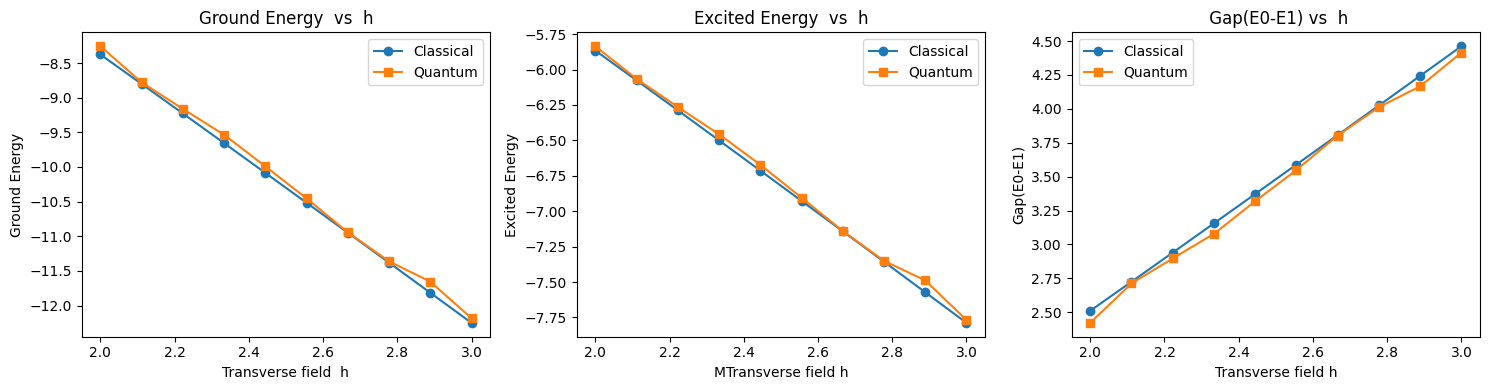

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
#damn this is performing better than VQD and SSVQE but still the results are  good, the gap error is negligible

In [21]:
def entanglement_entropy(statevector, n, cut=None):   
    if cut is None:
        cut = n//2   
    psi = statevector.data
    psi_matrix = psi.reshape(2**cut, 2**(n-cut))
    rhoA = psi_matrix @ psi_matrix.conj().T
    eigvals = np.linalg.eigvalsh(rhoA)
    eigvals = eigvals[eigvals > 1e-12]
    S = -np.sum(eigvals * np.log(eigvals))
    return S

In [22]:
J=1
d=3
n=10
entanglement='linear'
h_values =np.linspace(0,2,20)
entropies = []
for h in h_values:
    H=build_tfim(n,J,h)
    psi0,_, E0 = VQE_ground_energy(H, n, d, entanglement)
    S = entanglement_entropy(psi0, n)
    entropies.append(S)

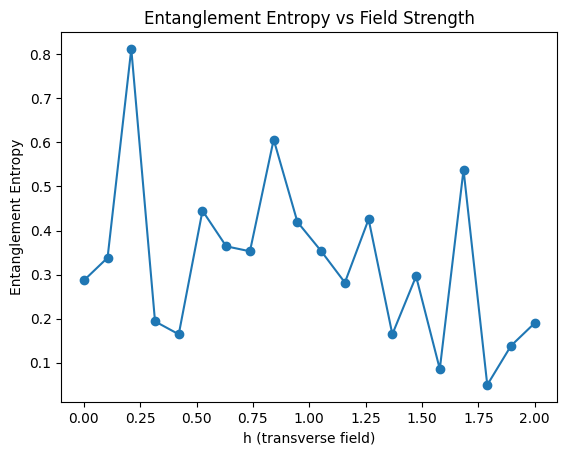

In [23]:
plt.plot(h_values, entropies, marker='o')
plt.xlabel("h (transverse field)")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Entropy vs Field Strength")
plt.show()

In [ ]:
#Its not showing the expected Behavior, maybe the ansatz is not good enough to capture the entanglement structure of the ground state, or maybe the optimization is getting stuck in local minima, I will try to debug this later

In [24]:
J=1
d=3
n=[4,6,8,10]
h=1
entanglement='linear'
entropies = []
for i in n:
    H=build_tfim(i,J,h)
    psi0,_,E0=VQE_ground_energy(H, i, d, entanglement)
    S=entanglement_entropy(psi0, i)
    entropies.append(S)

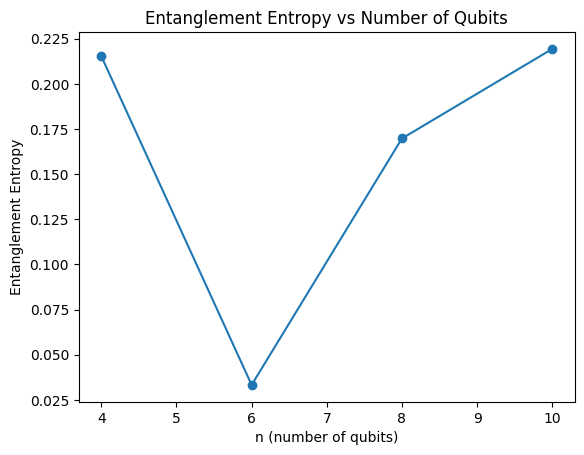

In [25]:
plt.plot(n, entropies, marker='o')
plt.xlabel("n (number of qubits)")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Entropy vs Number of Qubits")
plt.show()

In [27]:
# this is also not what I expected, I expected the entanglement entropy to increase with n and then saturate but here its just increasing